https://github.com/akul-ameya/compvis

# Stage 2 — Final Results Summary

This notebook consolidates all experimental metrics and displays all figures from the Stage 2 experiments on **Tiny ImageNet** and **CIFAR-100** datasets.


In [1]:
import os, sys
# Ensure we're in the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())


Working directory: /mnt/data/cv


In [2]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, HTML


In [3]:
# Load all metrics.json files directly from results/
all_metrics = {}
for root, dirs, files in os.walk("results"):
    if "metrics.json" in files and "_archived" not in root:
        rel = os.path.relpath(root, "results")
        parts = rel.split("/")
        key = "/".join(parts[:-1])  # drop timestamp dir
        with open(os.path.join(root, "metrics.json")) as f:
            data = json.load(f)
        all_metrics[key] = {
            "run_dir": rel,
            "top1": data.get("top1"),
            "top5": data.get("top5"),
            "macro_acc": data.get("macro_acc"),
            "worst_k_acc": data.get("worst_k_acc"),
            "ece": data.get("ece"),
            "ece_after_scaling": data.get("temperature_scaling", {}).get("ece_after_scaling"),
            "linear_probe_top1": data.get("linear_probe_top1"),
            "feature_effective_rank": data.get("feature_effective_rank"),
            "mean_corruption_acc": data.get("mean_corruption_acc"),
            "corruption": data.get("corruption"),
        }

print(f"Loaded metrics for {len(all_metrics)} experiment runs:")
for k in sorted(all_metrics.keys()):
    print(f"  - {k}")


Loaded metrics for 18 experiment runs:
  - cifar100/adaptive_15x_predicted_utility/resnet18
  - cifar100/adaptive_15x_predicted_utility_sa/resnet18
  - cifar100/baseline/resnet18
  - cifar100/ceiling/resnet18
  - cifar100/uniform_15x/resnet18
  - tiny_imagenet/adaptive_15x_hard_class/resnet18
  - tiny_imagenet/adaptive_15x_predicted_utility/mobilenet_v3_small
  - tiny_imagenet/adaptive_15x_predicted_utility/resnet18
  - tiny_imagenet/adaptive_15x_predicted_utility_sa/resnet18
  - tiny_imagenet/adaptive_15x_uncertainty/resnet18
  - tiny_imagenet/baseline/mobilenet_v3_small
  - tiny_imagenet/baseline/resnet18
  - tiny_imagenet/ceiling/mobilenet_v3_small
  - tiny_imagenet/ceiling/resnet18
  - tiny_imagenet/uniform_10x/resnet18
  - tiny_imagenet/uniform_15x/mobilenet_v3_small
  - tiny_imagenet/uniform_15x/resnet18
  - tiny_imagenet/uniform_5x/resnet18


## Tiny ImageNet — ResNet-18 Results

In [4]:
ti_keys = [
    ("tiny_imagenet/baseline/resnet18", "Baseline (5% real only)"),
    ("tiny_imagenet/uniform_5x/resnet18", "Uniform 5x"),
    ("tiny_imagenet/uniform_10x/resnet18", "Uniform 10x"),
    ("tiny_imagenet/uniform_15x/resnet18", "Uniform 15x"),
    ("tiny_imagenet/adaptive_15x_hard_class/resnet18", "Adaptive 15x (Hard-class)"),
    ("tiny_imagenet/adaptive_15x_uncertainty/resnet18", "Adaptive 15x (Uncertainty)"),
    ("tiny_imagenet/adaptive_15x_predicted_utility/resnet18", "Adaptive 15x (Pred. Utility)"),
    ("tiny_imagenet/adaptive_15x_predicted_utility_sa/resnet18", "Adaptive 15x (Pred. Utility + SA)"),
    ("tiny_imagenet/ceiling/resnet18", "Ceiling (100% real)"),
]

rows = []
for key, label in ti_keys:
    m = all_metrics.get(key, {})
    rows.append({
        "Strategy": label,
        "Top-1 (%)": f"{m['top1']*100:.1f}" if m.get('top1') is not None else "-",
        "Top-5 (%)": f"{m['top5']*100:.1f}" if m.get('top5') is not None else "-",
        "Worst-k (%)": f"{m['worst_k_acc']*100:.1f}" if m.get('worst_k_acc') is not None else "-",
        "ECE": f"{m['ece']:.4f}" if m.get('ece') is not None else "-",
        "ECE (cal.)": f"{m['ece_after_scaling']:.4f}" if m.get('ece_after_scaling') is not None else "-",
        "Eff. Rank": f"{m['feature_effective_rank']:.1f}" if m.get('feature_effective_rank') is not None else "-",
        "Corr. Acc (%)": f"{m['mean_corruption_acc']*100:.1f}" if m.get('mean_corruption_acc') is not None else "-",
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(index=False)))


Strategy,Top-1 (%),Top-5 (%),Worst-k (%),ECE,ECE (cal.),Eff. Rank,Corr. Acc (%)
Baseline (5% real only),49.4,75.6,16.3,0.1512,0.0245,31.8,37.5
Uniform 5x,51.6,75.4,21.5,0.1580,0.0383,35.8,35.2
Uniform 10x,50.0,74.6,20.4,0.0574,0.0302,34.5,35.3
Uniform 15x,49.9,75.7,17.7,0.0694,0.0325,33.7,35.4
Adaptive 15x (Hard-class),50.0,75.2,21.5,0.0572,0.0304,34.4,35.2
Adaptive 15x (Uncertainty),50.0,75.2,20.2,0.0582,0.0380,34.1,34.5
Adaptive 15x (Pred. Utility),49.3,74.9,21.4,0.0394,0.0337,34.0,34.3
Adaptive 15x (Pred. Utility + SA),43.0,69.5,14.5,0.0678,0.0161,32.1,29.7
Ceiling (100% real),71.0,89.3,48.6,0.0821,0.0358,34.1,47.8


## Tiny ImageNet — MobileNet-V3-Small (Architecture Generalization)

In [5]:
mob_keys = [
    ("tiny_imagenet/baseline/mobilenet_v3_small", "Baseline (5% real only)"),
    ("tiny_imagenet/uniform_15x/mobilenet_v3_small", "Uniform 15x"),
    ("tiny_imagenet/adaptive_15x_predicted_utility/mobilenet_v3_small", "Adaptive 15x (Pred. Utility)"),
    ("tiny_imagenet/ceiling/mobilenet_v3_small", "Ceiling (100% real)"),
]

rows = []
for key, label in mob_keys:
    m = all_metrics.get(key, {})
    rows.append({
        "Strategy": label,
        "Top-1 (%)": f"{m['top1']*100:.1f}" if m.get('top1') is not None else "-",
        "Top-5 (%)": f"{m['top5']*100:.1f}" if m.get('top5') is not None else "-",
        "Worst-k (%)": f"{m['worst_k_acc']*100:.1f}" if m.get('worst_k_acc') is not None else "-",
        "ECE": f"{m['ece']:.4f}" if m.get('ece') is not None else "-",
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(index=False)))


Strategy,Top-1 (%),Top-5 (%),Worst-k (%),ECE
Baseline (5% real only),50.3,77.7,18.4,0.0939
Uniform 15x,55.2,79.7,26.4,0.0385
Adaptive 15x (Pred. Utility),55.0,79.8,27.6,0.0551
Ceiling (100% real),71.7,90.6,48.0,0.1022


## CIFAR-100 — ResNet-18 Results

In [6]:
cifar_keys = [
    ("cifar100/baseline/resnet18", "Baseline (5% real only)"),
    ("cifar100/uniform_15x/resnet18", "Uniform 15x"),
    ("cifar100/adaptive_15x_predicted_utility/resnet18", "Adaptive 15x (Pred. Utility)"),
    ("cifar100/adaptive_15x_predicted_utility_sa/resnet18", "Adaptive 15x (Pred. Utility + SA)"),
    ("cifar100/ceiling/resnet18", "Ceiling (100% real)"),
]

rows = []
for key, label in cifar_keys:
    m = all_metrics.get(key, {})
    rows.append({
        "Strategy": label,
        "Top-1 (%)": f"{m['top1']*100:.1f}" if m.get('top1') is not None else "-",
        "Top-5 (%)": f"{m['top5']*100:.1f}" if m.get('top5') is not None else "-",
        "Worst-k (%)": f"{m['worst_k_acc']*100:.1f}" if m.get('worst_k_acc') is not None else "-",
        "ECE": f"{m['ece']:.4f}" if m.get('ece') is not None else "-",
        "ECE (cal.)": f"{m['ece_after_scaling']:.4f}" if m.get('ece_after_scaling') is not None else "-",
        "Eff. Rank": f"{m['feature_effective_rank']:.1f}" if m.get('feature_effective_rank') is not None else "-",
        "Corr. Acc (%)": f"{m['mean_corruption_acc']*100:.1f}" if m.get('mean_corruption_acc') is not None else "-",
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(index=False)))


Strategy,Top-1 (%),Top-5 (%),Worst-k (%),ECE,ECE (cal.),Eff. Rank,Corr. Acc (%)
Baseline (5% real only),56.9,85.6,30.1,0.1470,0.0479,28.2,41.0
Uniform 15x,58.6,86.9,34.7,0.1067,0.0327,30.3,40.0
Adaptive 15x (Pred. Utility),64.2,86.8,40.2,0.2441,0.0495,36.0,42.6
Adaptive 15x (Pred. Utility + SA),53.3,81.8,28.0,0.0673,0.0585,29.0,36.1
Ceiling (100% real),82.0,96.3,67.0,0.1151,0.0132,34.2,55.8


## Figures

All Stage 2 experiment figures.


### Figure 1: Learning Curves

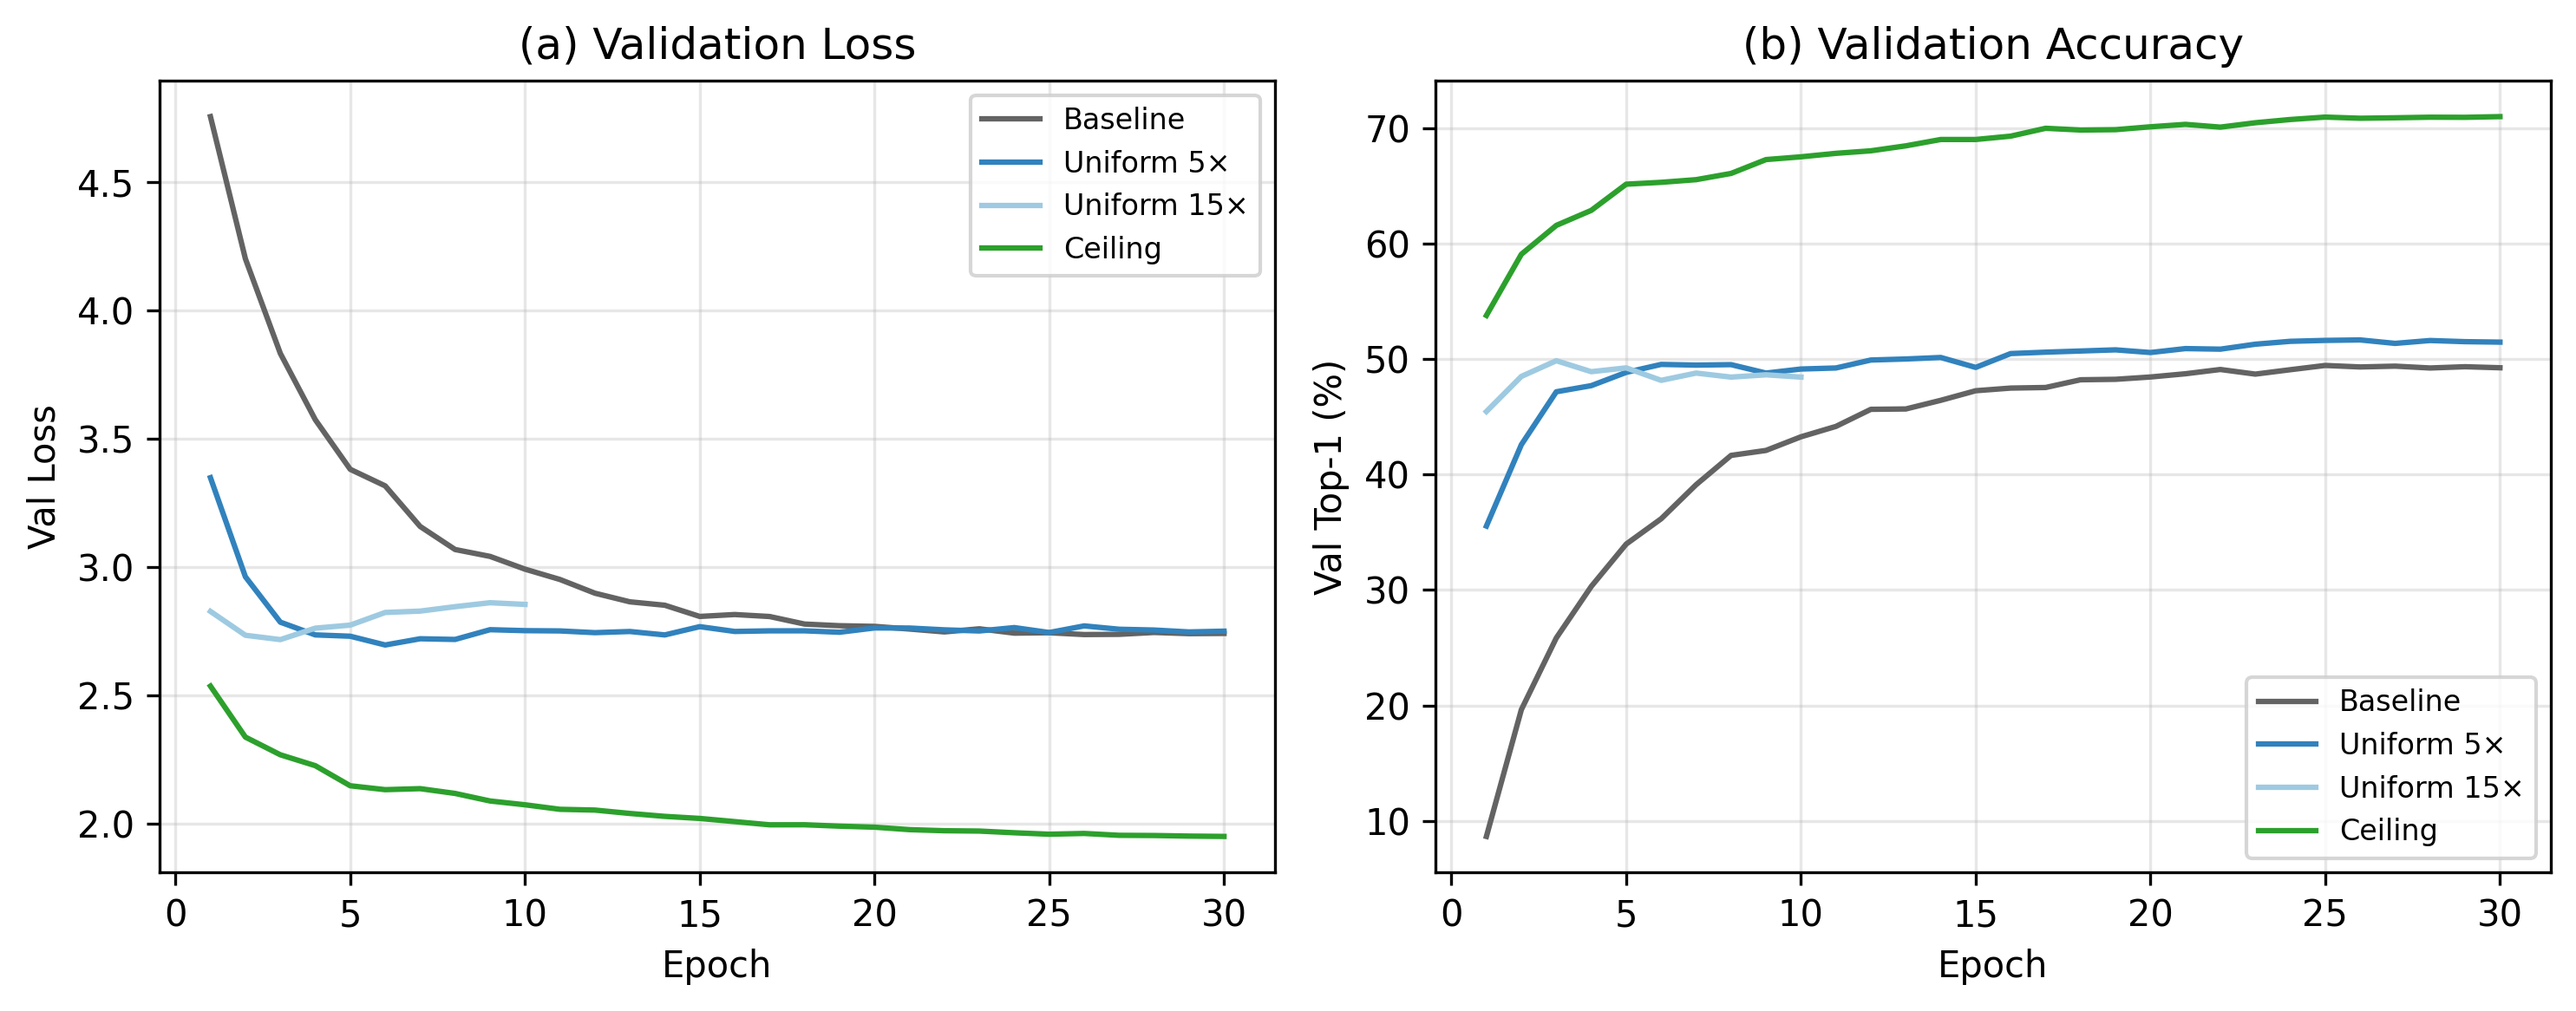

In [7]:
display(Image(filename="figures/stage2/fig1_learning_curves.png", width=900))

### Figure 2: Scaling Curves (Top-1 vs Synthetic Budget)

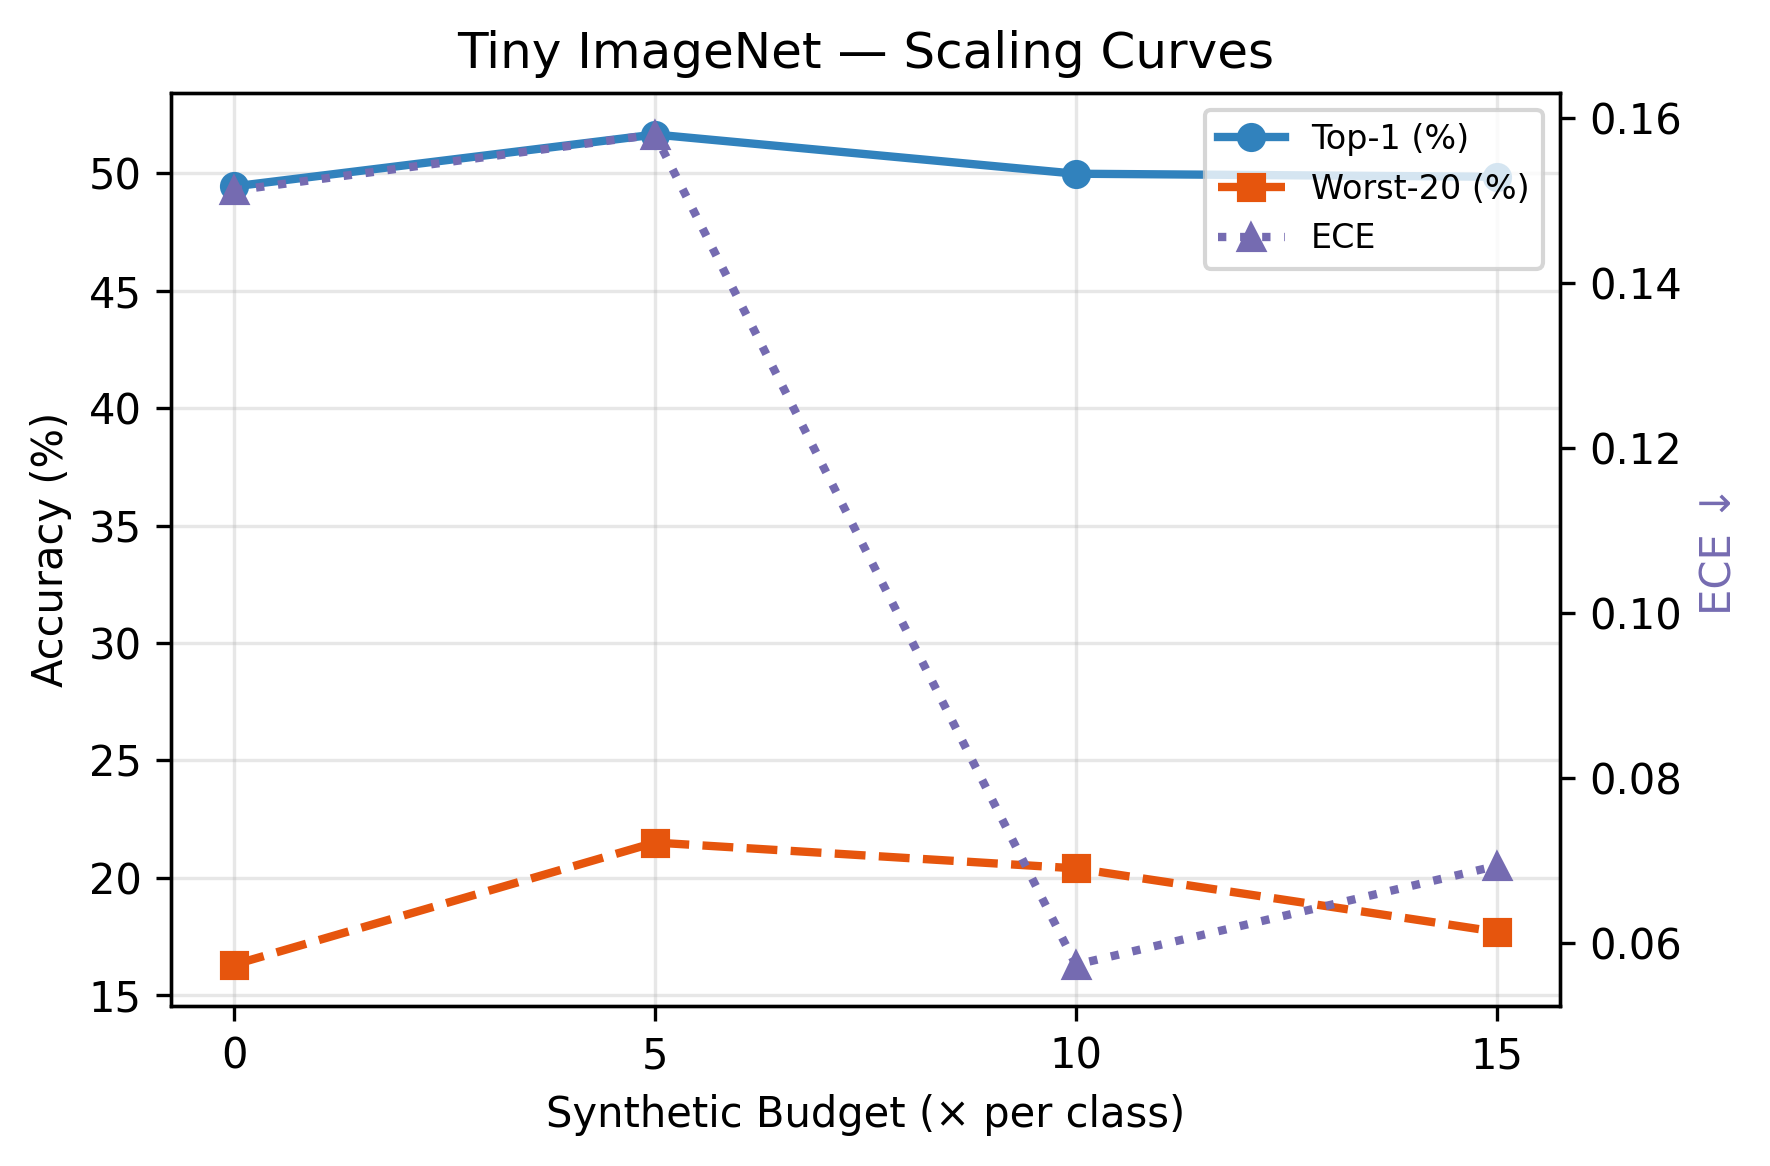

In [8]:
display(Image(filename="figures/stage2/fig2_scaling_curves.png", width=900))

### Figure 3: Policy Comparison

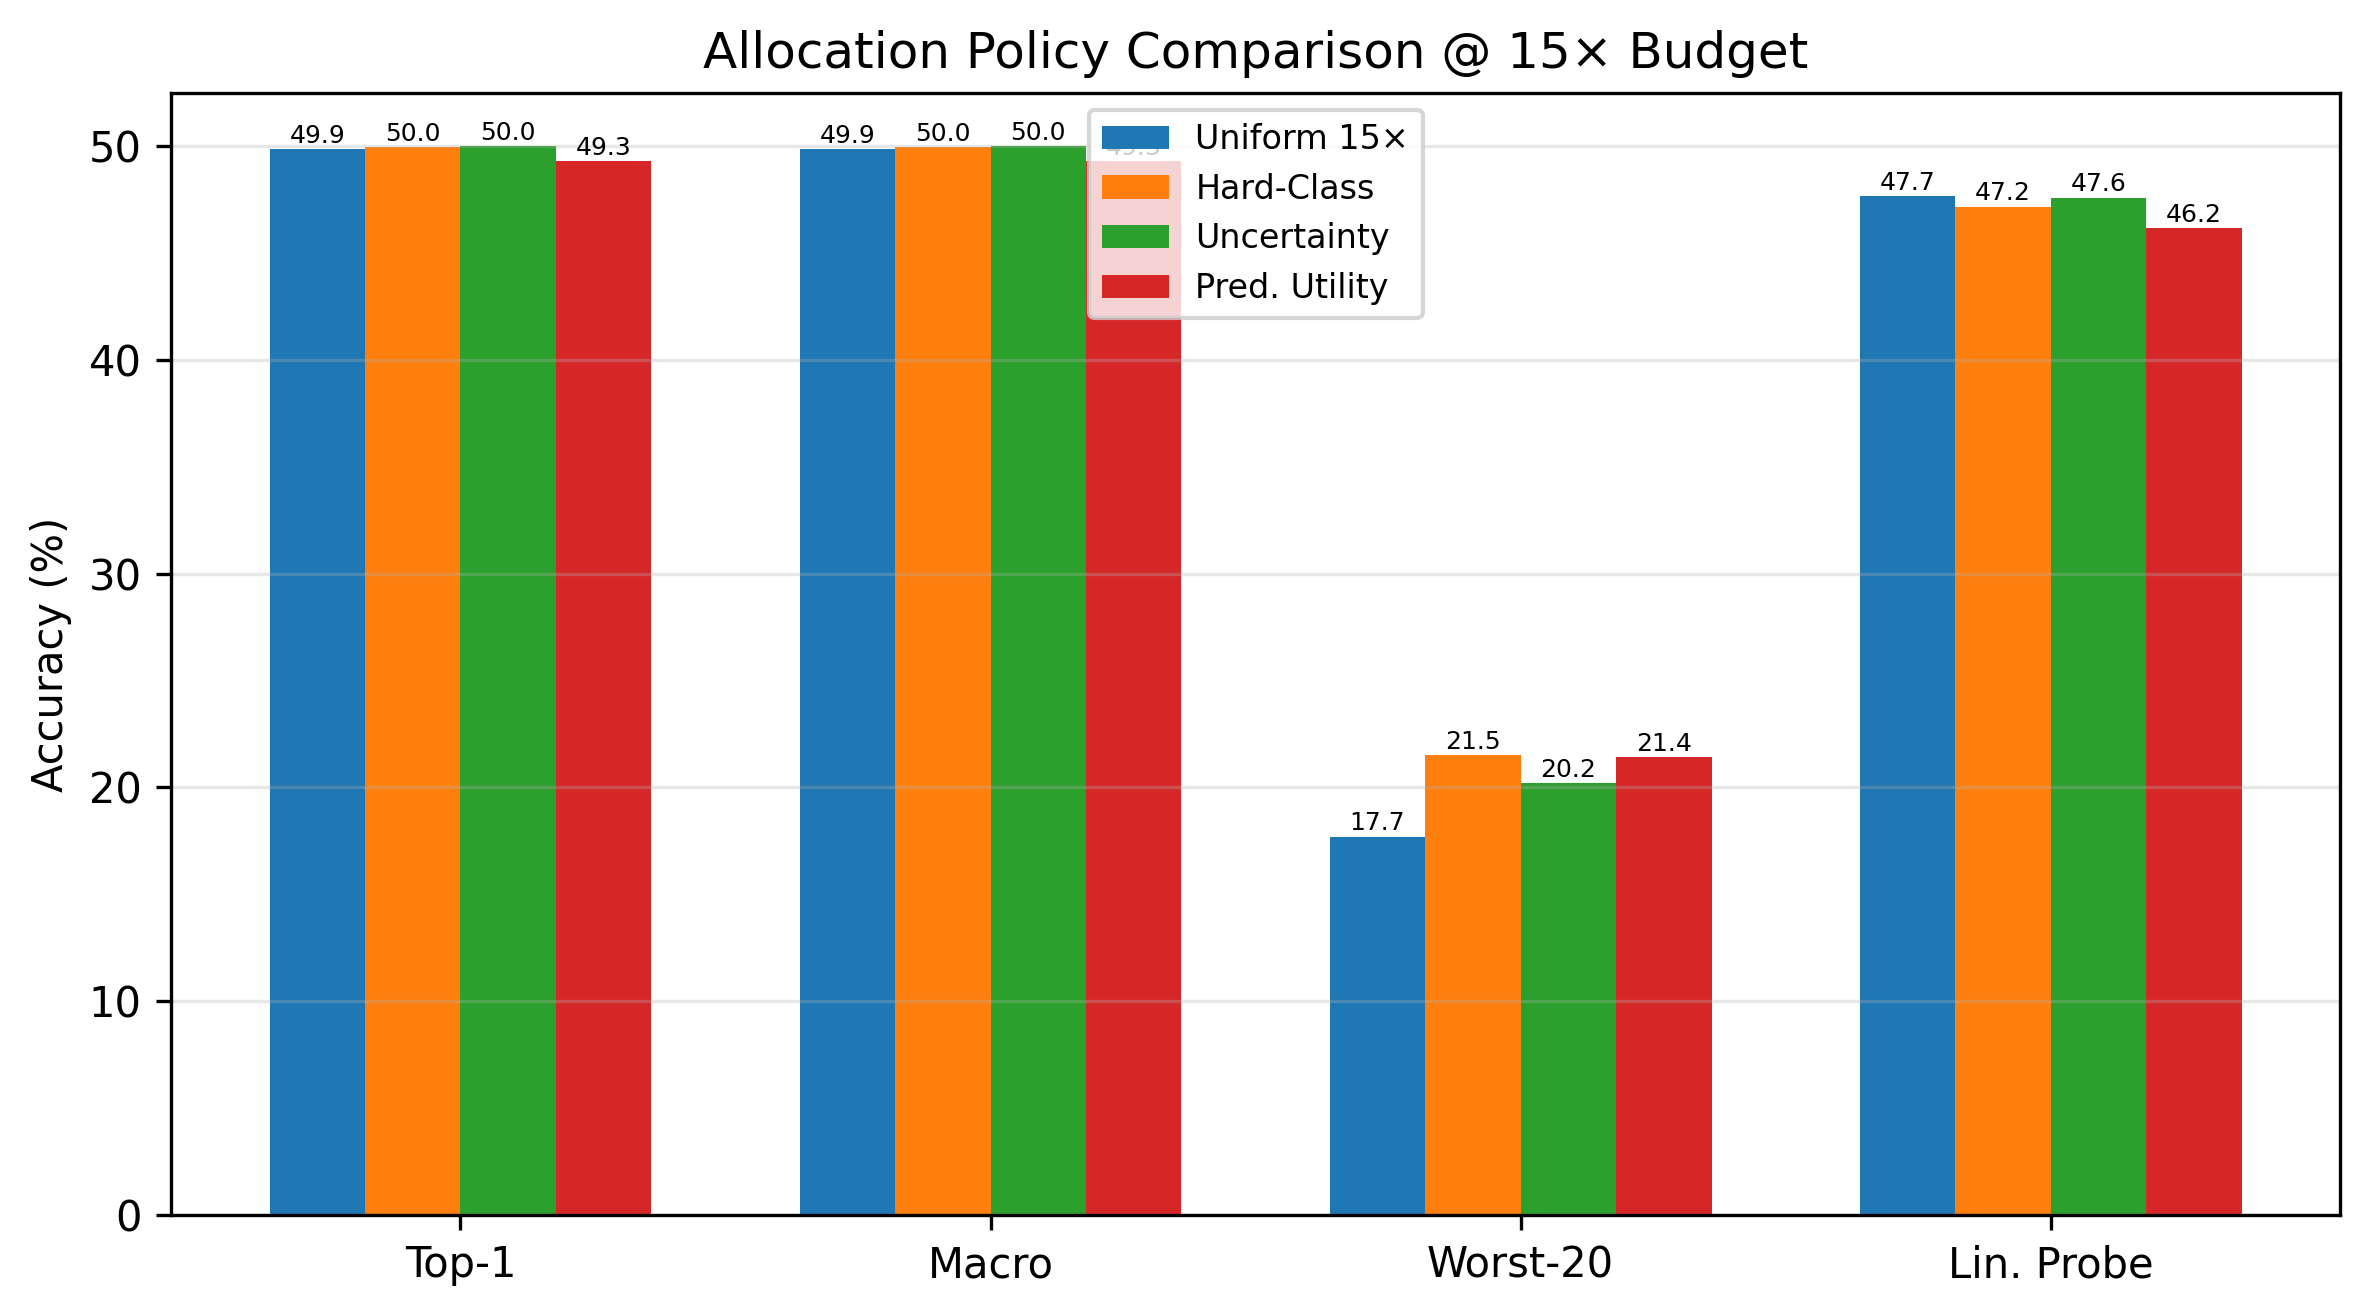

In [9]:
display(Image(filename="figures/stage2/fig3_policy_comparison.png", width=900))

### Figure 4: Per-Class Accuracy Delta (Adaptive vs Uniform)

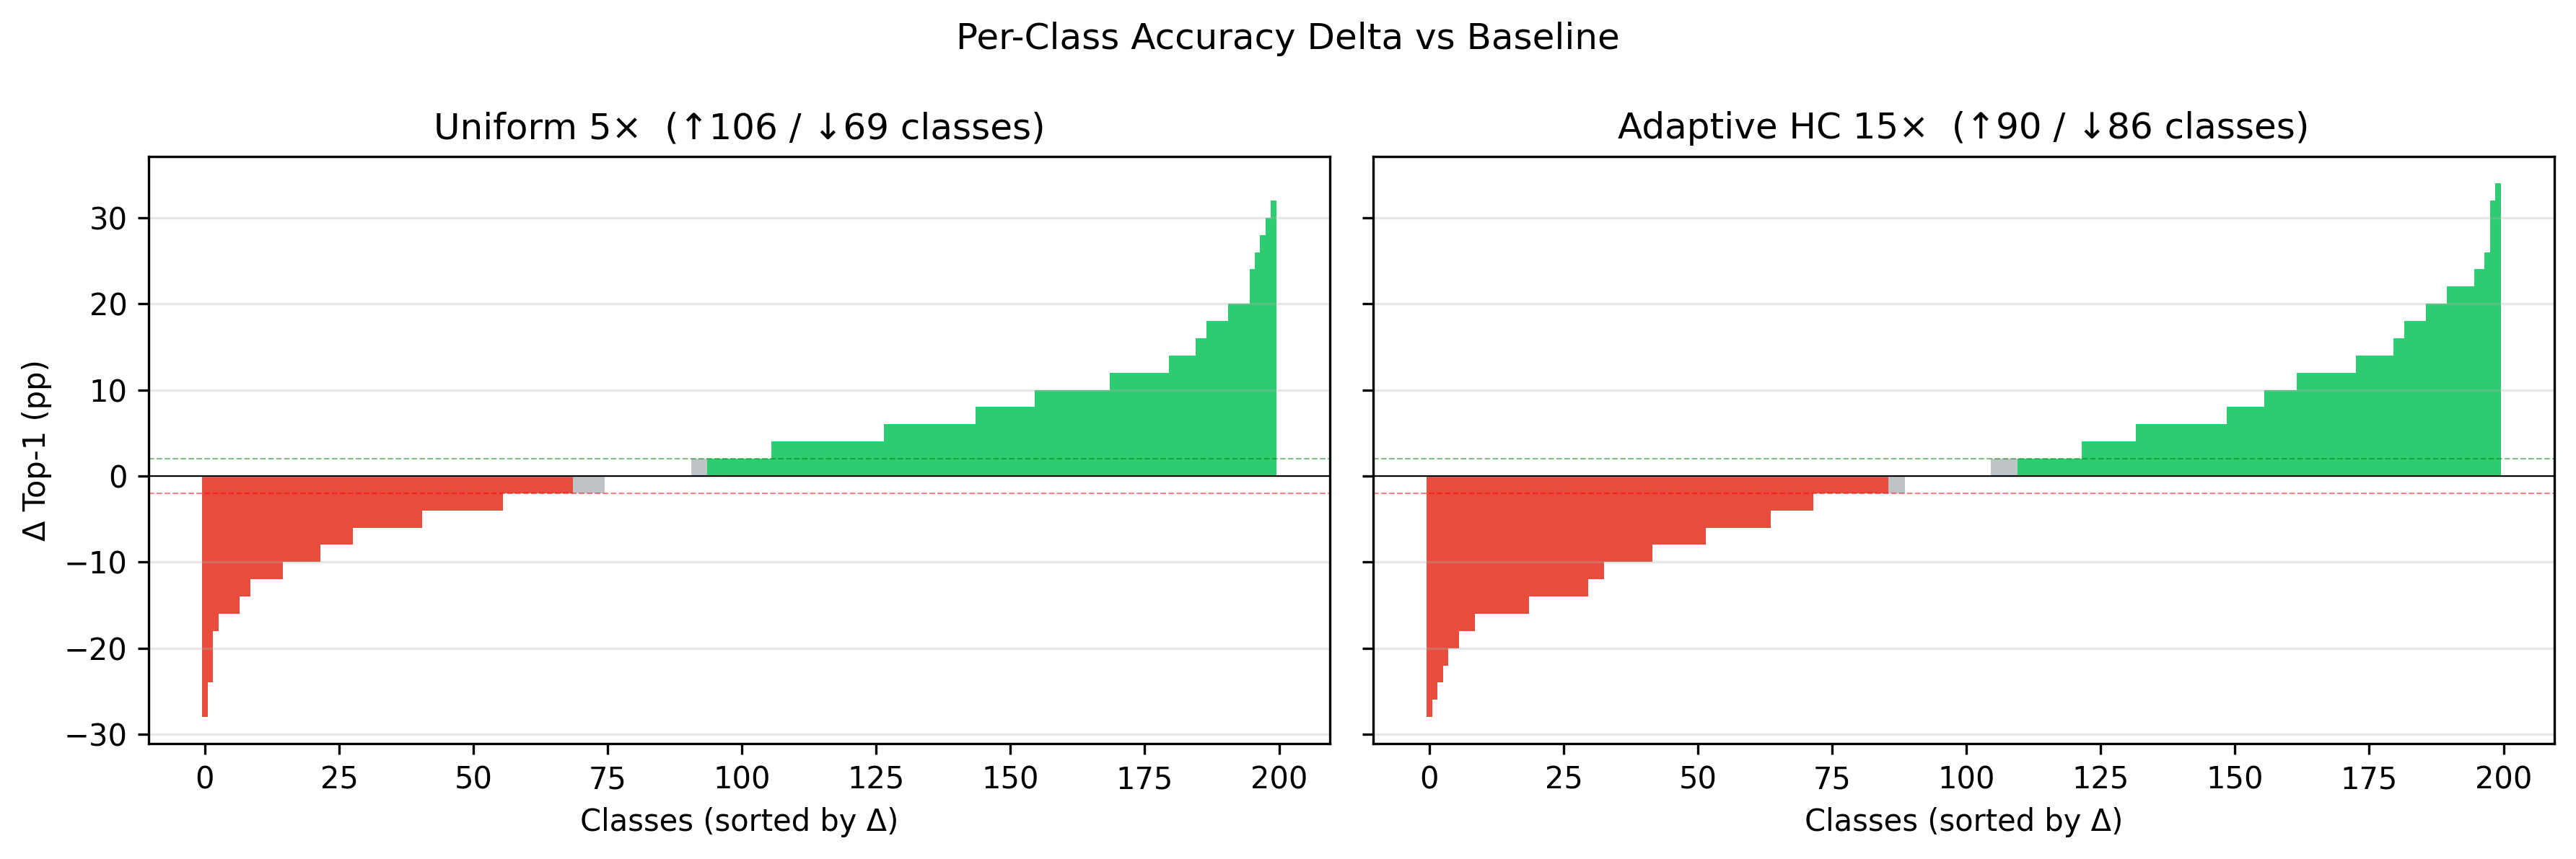

In [10]:
display(Image(filename="figures/stage2/fig4_perclass_delta.png", width=900))

### Figure 5: Corruption Robustness

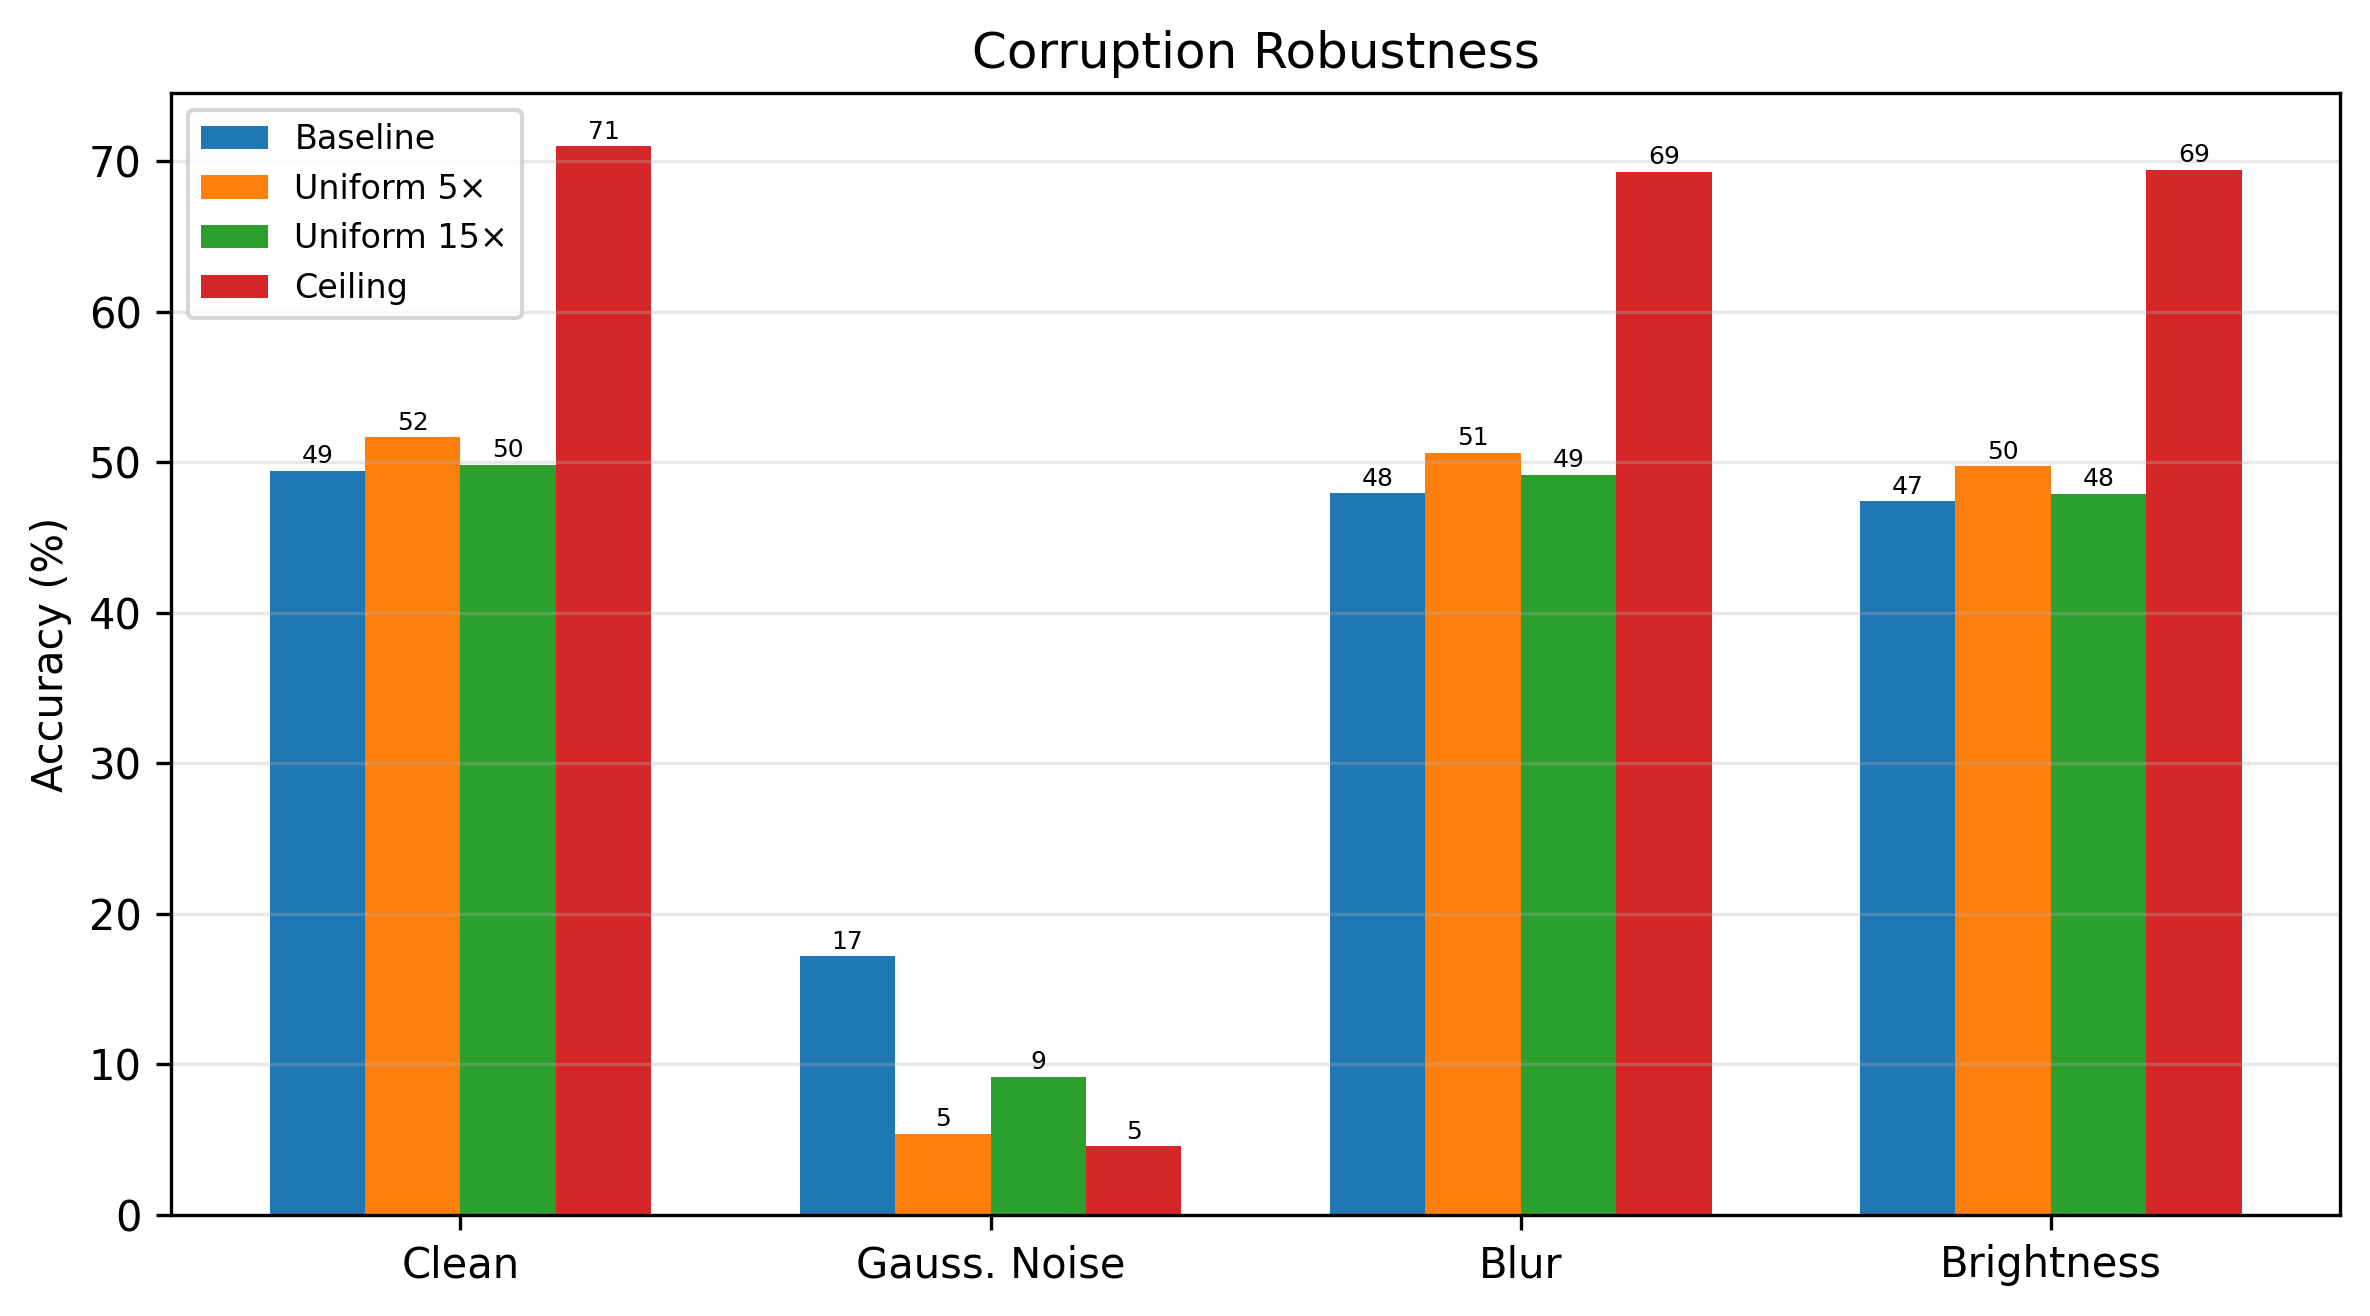

In [11]:
display(Image(filename="figures/stage2/fig5_corruption_robustness.png", width=900))

### Figure 6: Feature Eigenvalue Spectrum

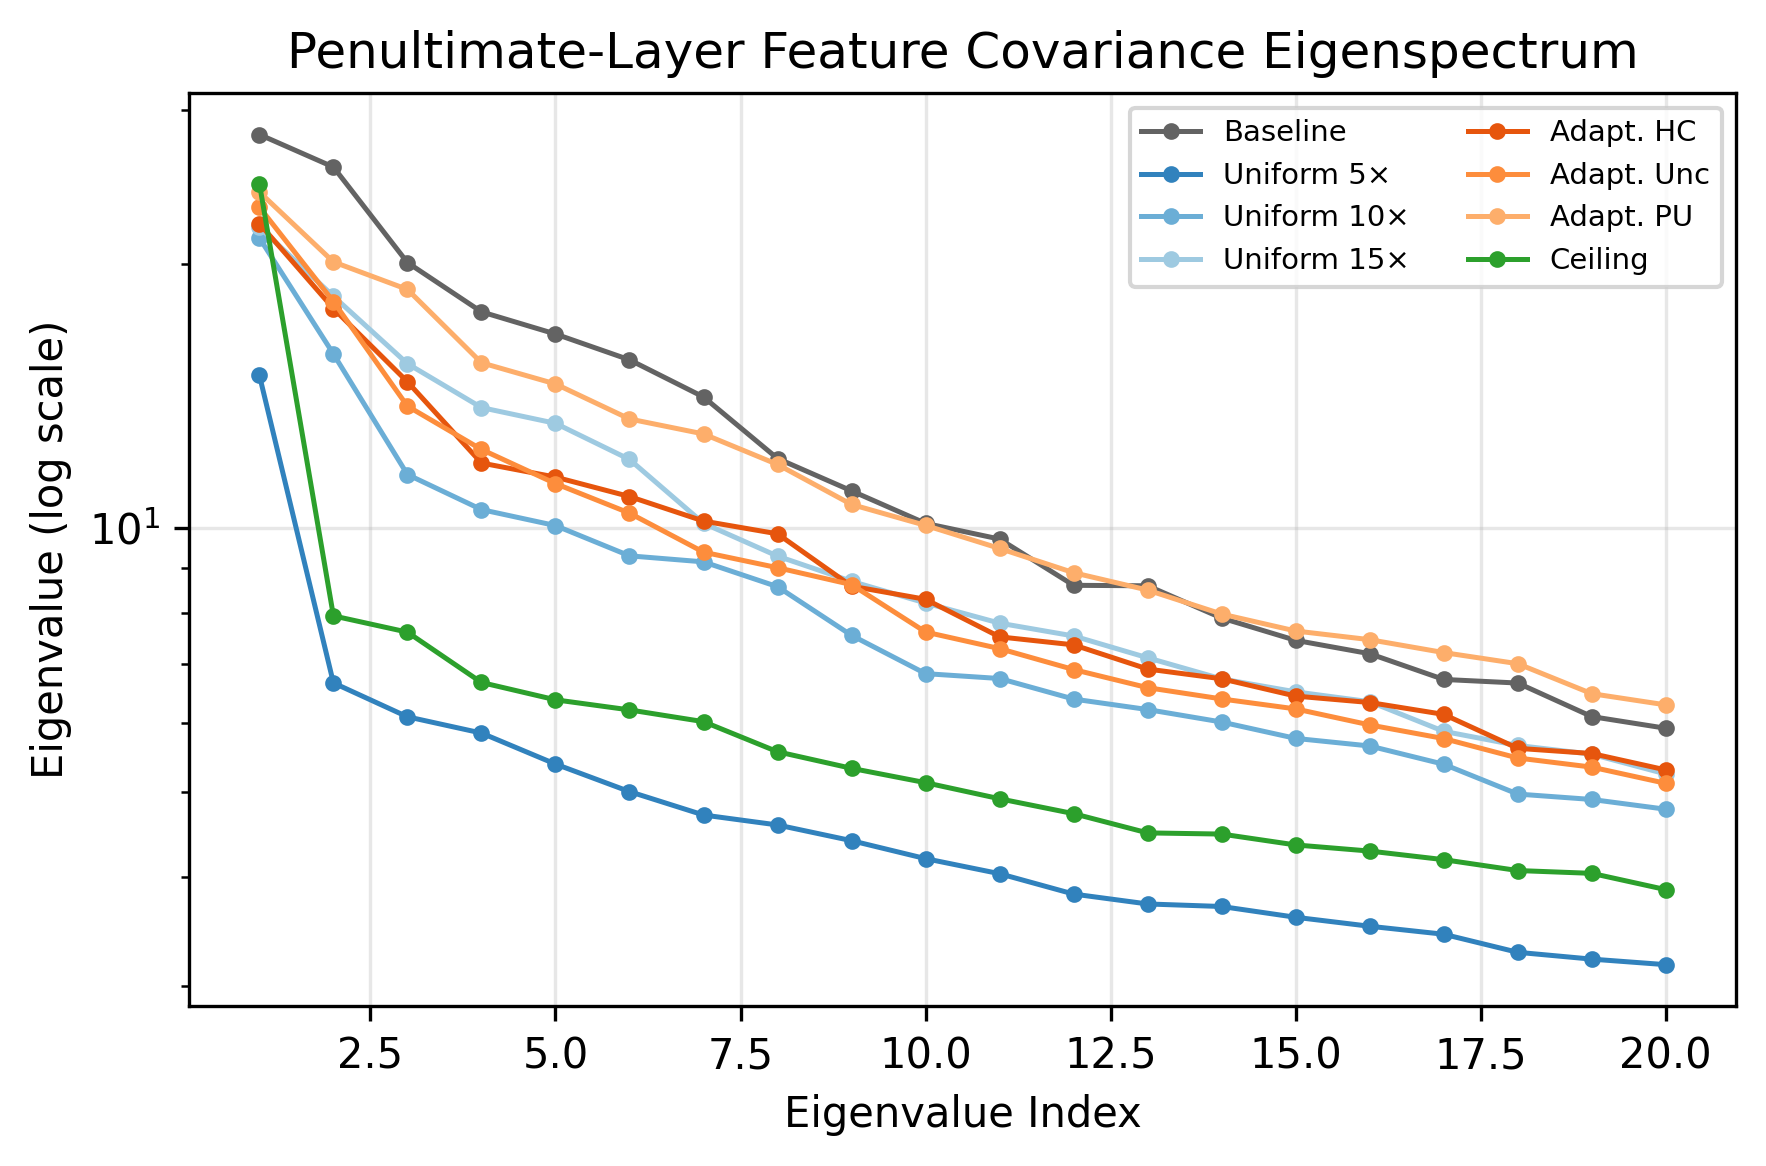

In [12]:
display(Image(filename="figures/stage2/fig6_eigenvalue_spectrum.png", width=900))

### Figure 7: Tiny ImageNet Summary (All Strategies)

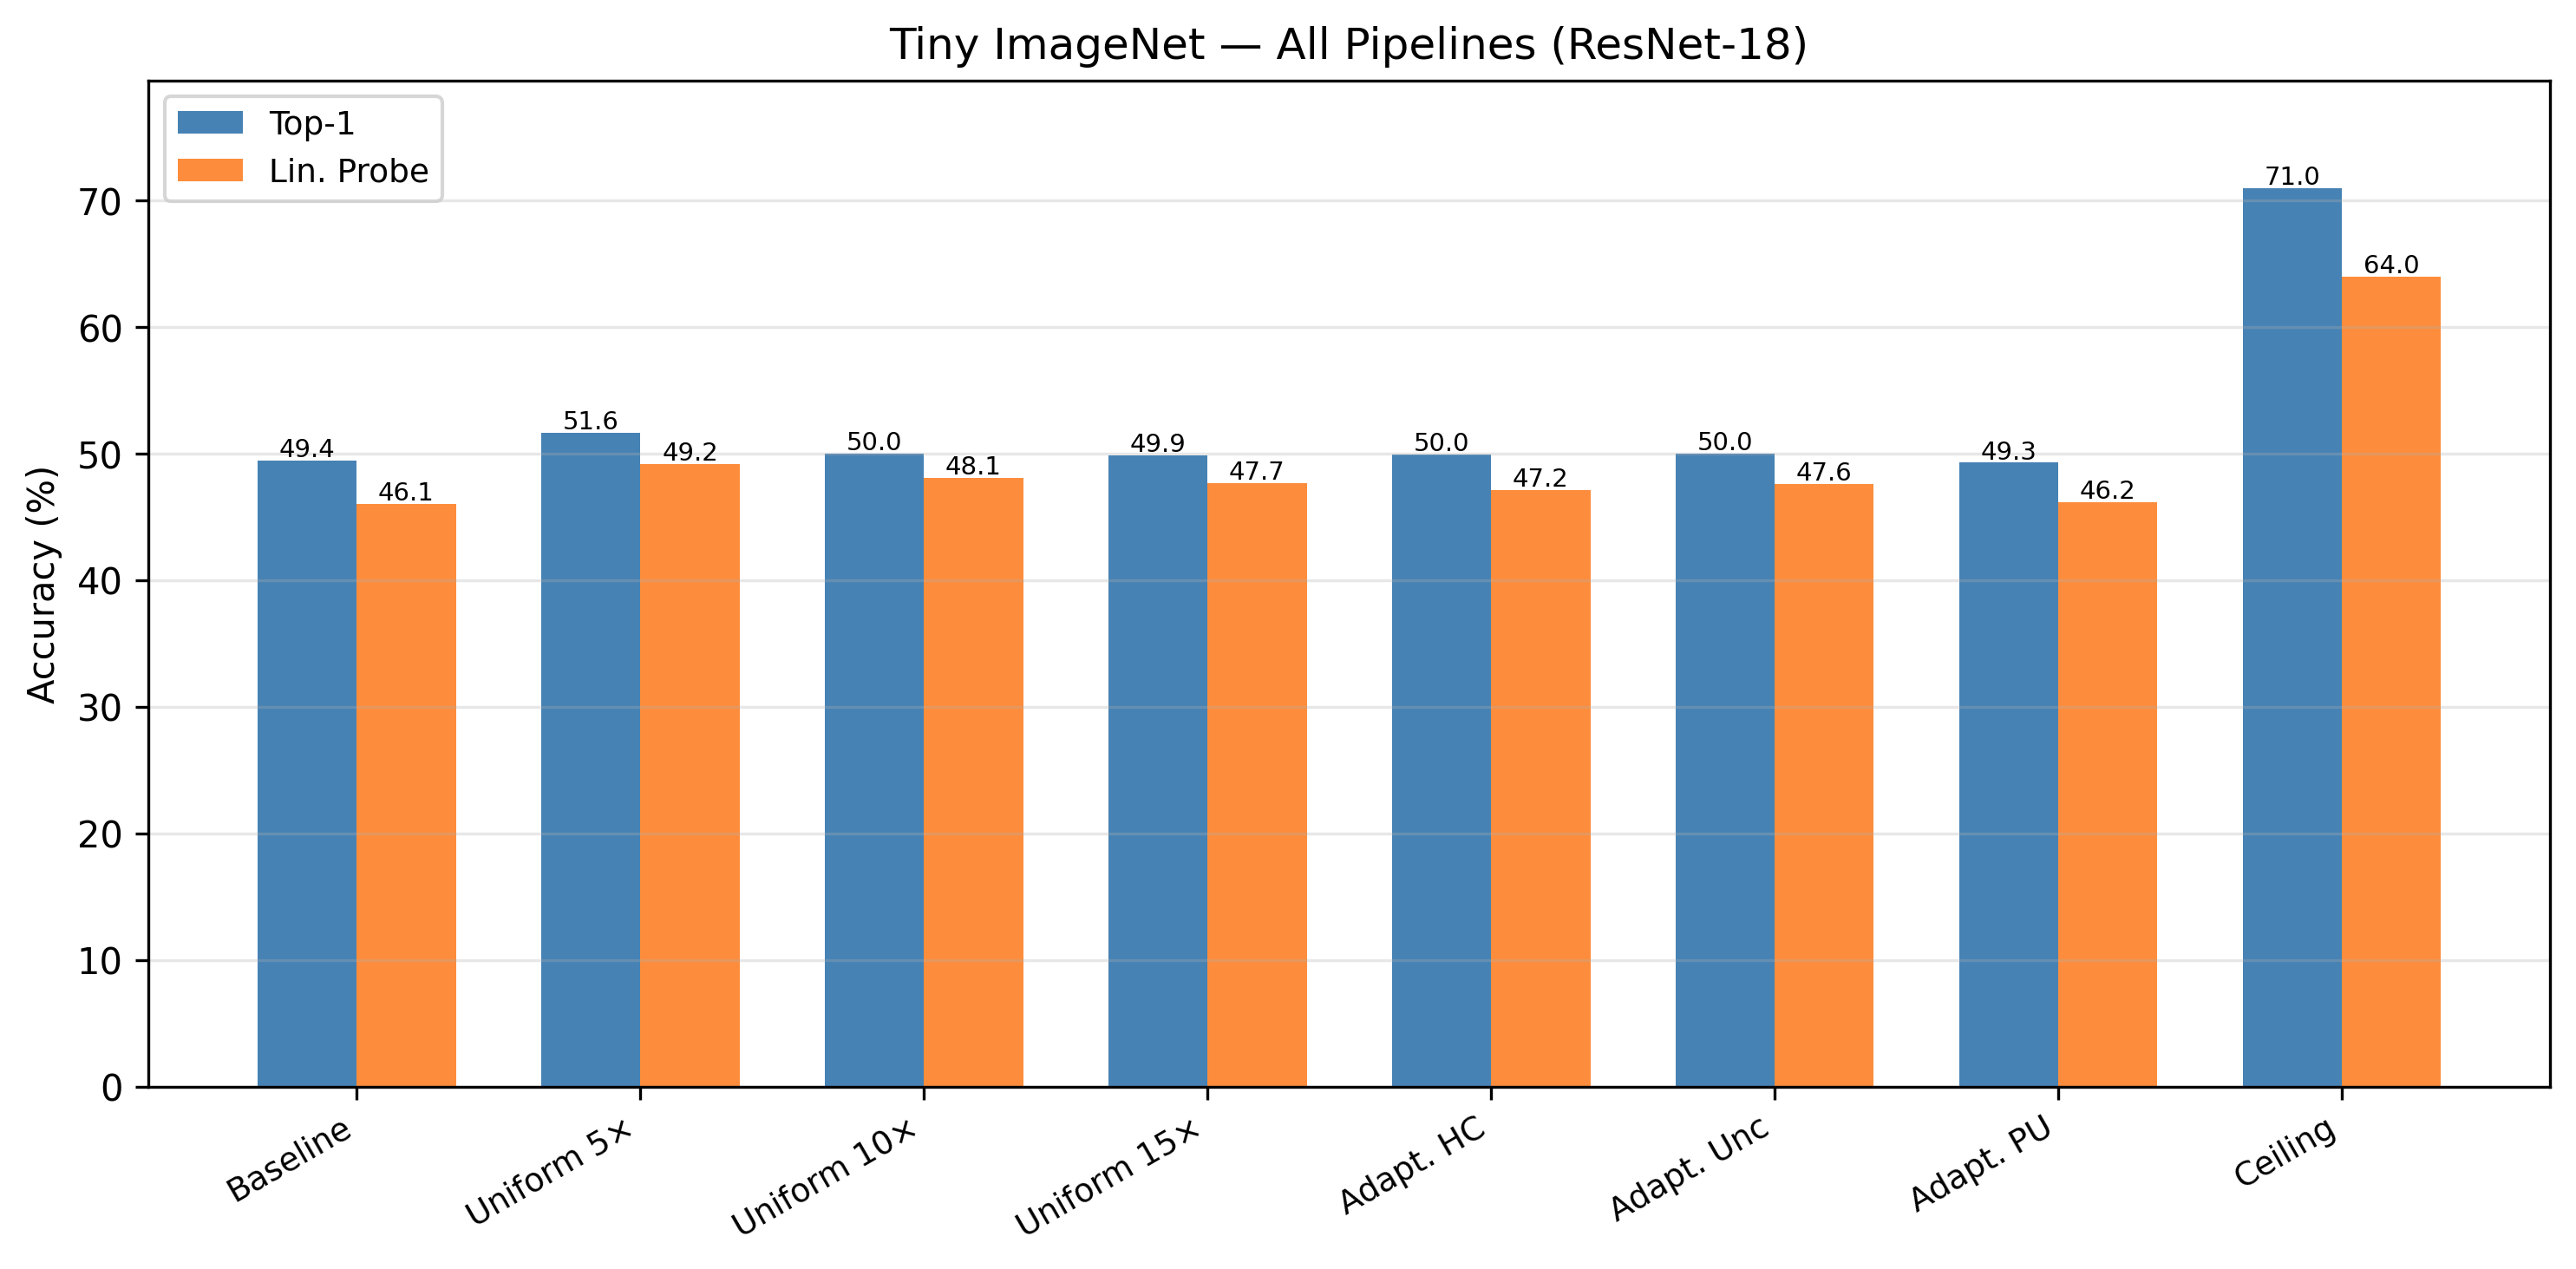

In [13]:
display(Image(filename="figures/stage2/fig7_summary_top1.png", width=900))

### Figure 8: Style Alignment Ablation (Tiny ImageNet)

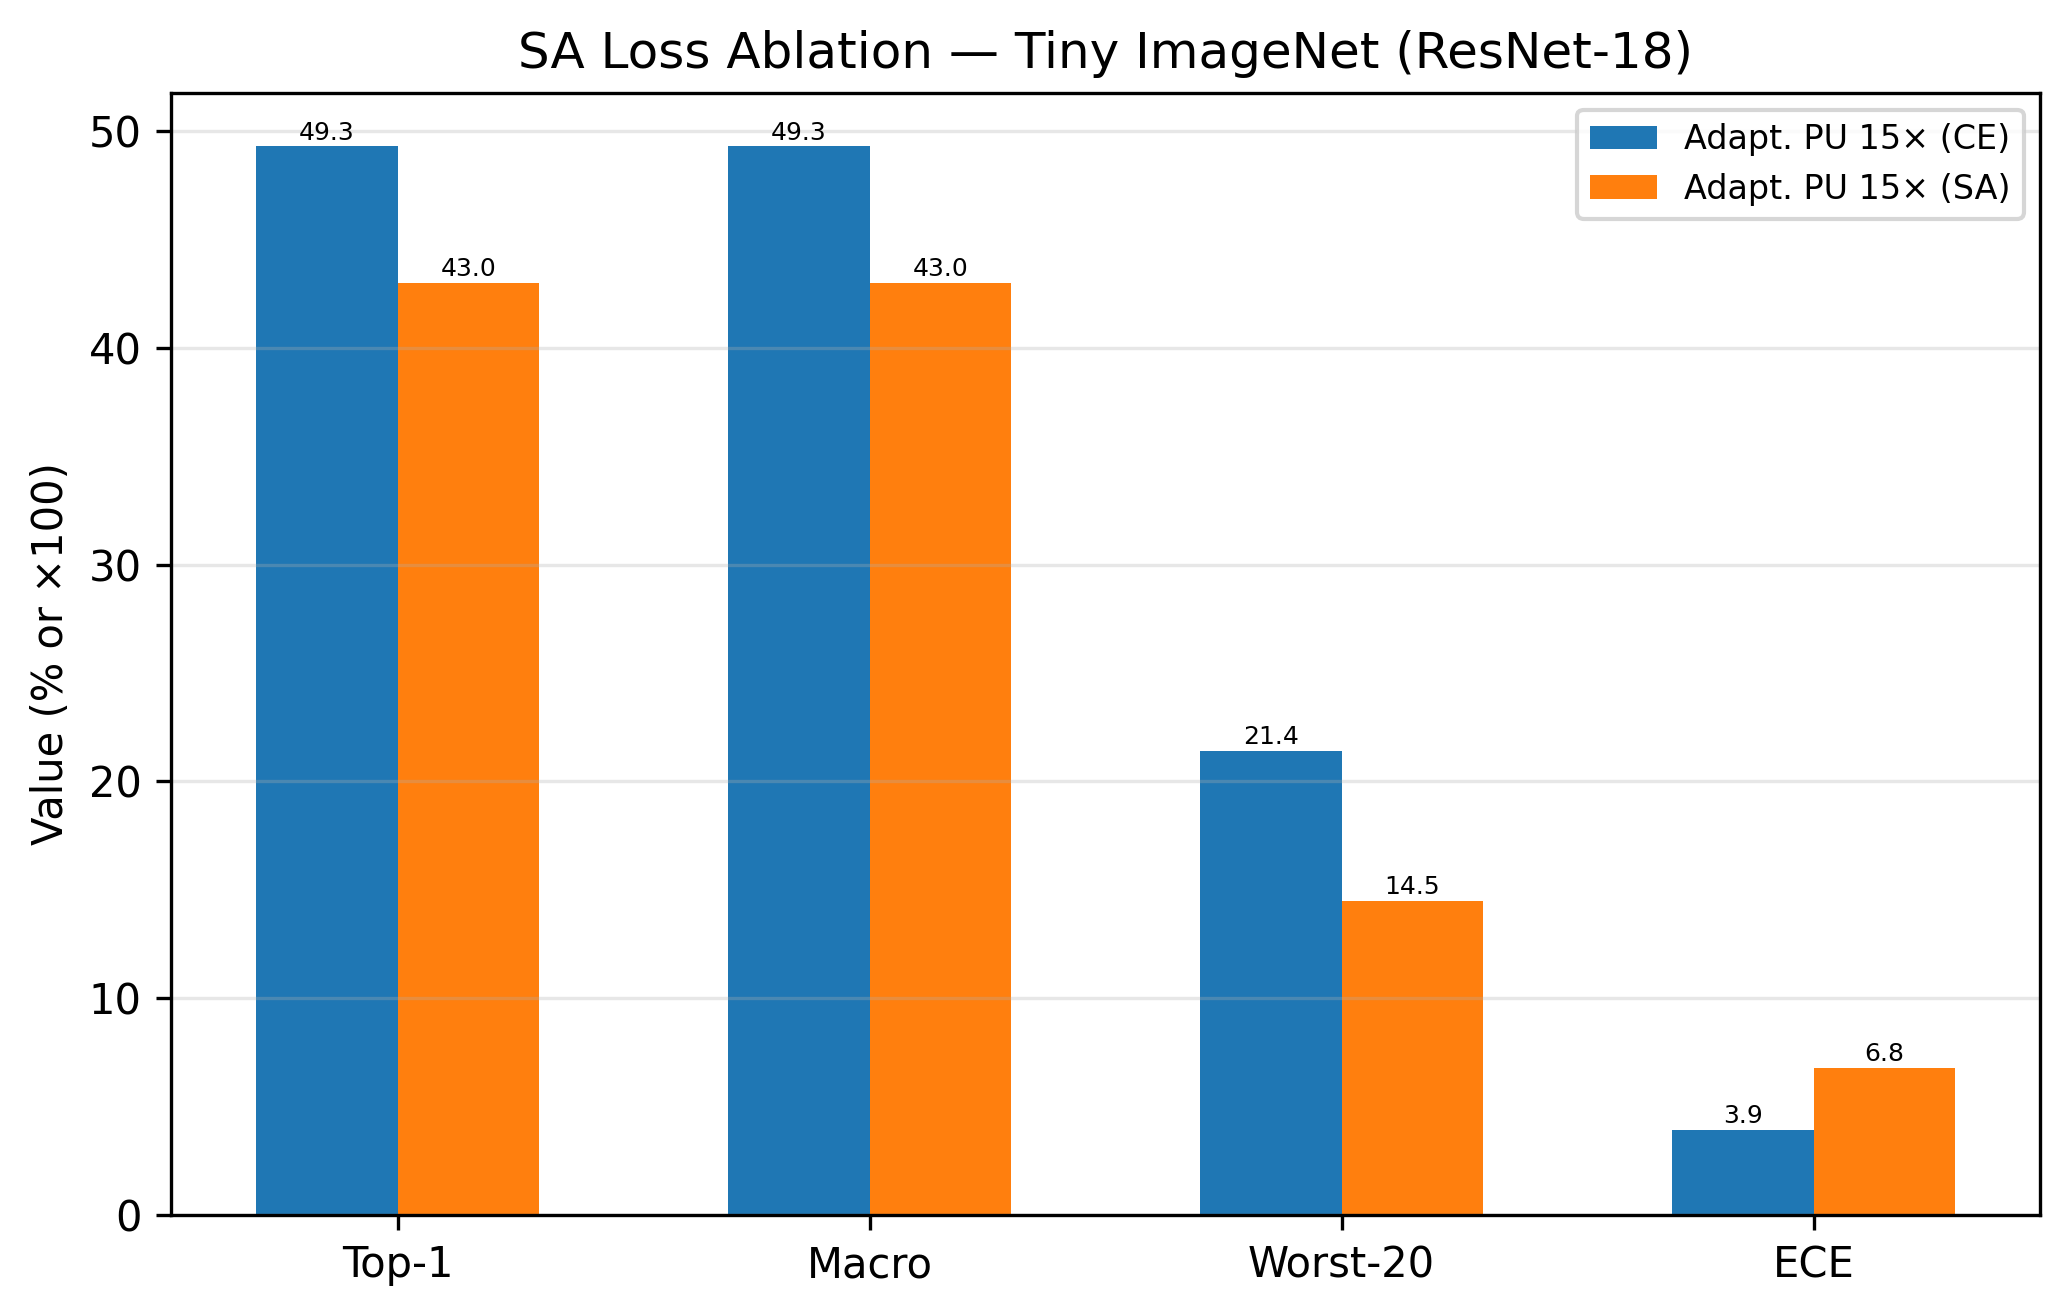

In [14]:
display(Image(filename="figures/stage2/fig8_sa_ablation_tiny.png", width=900))

### Figure 9: CIFAR-100 Summary

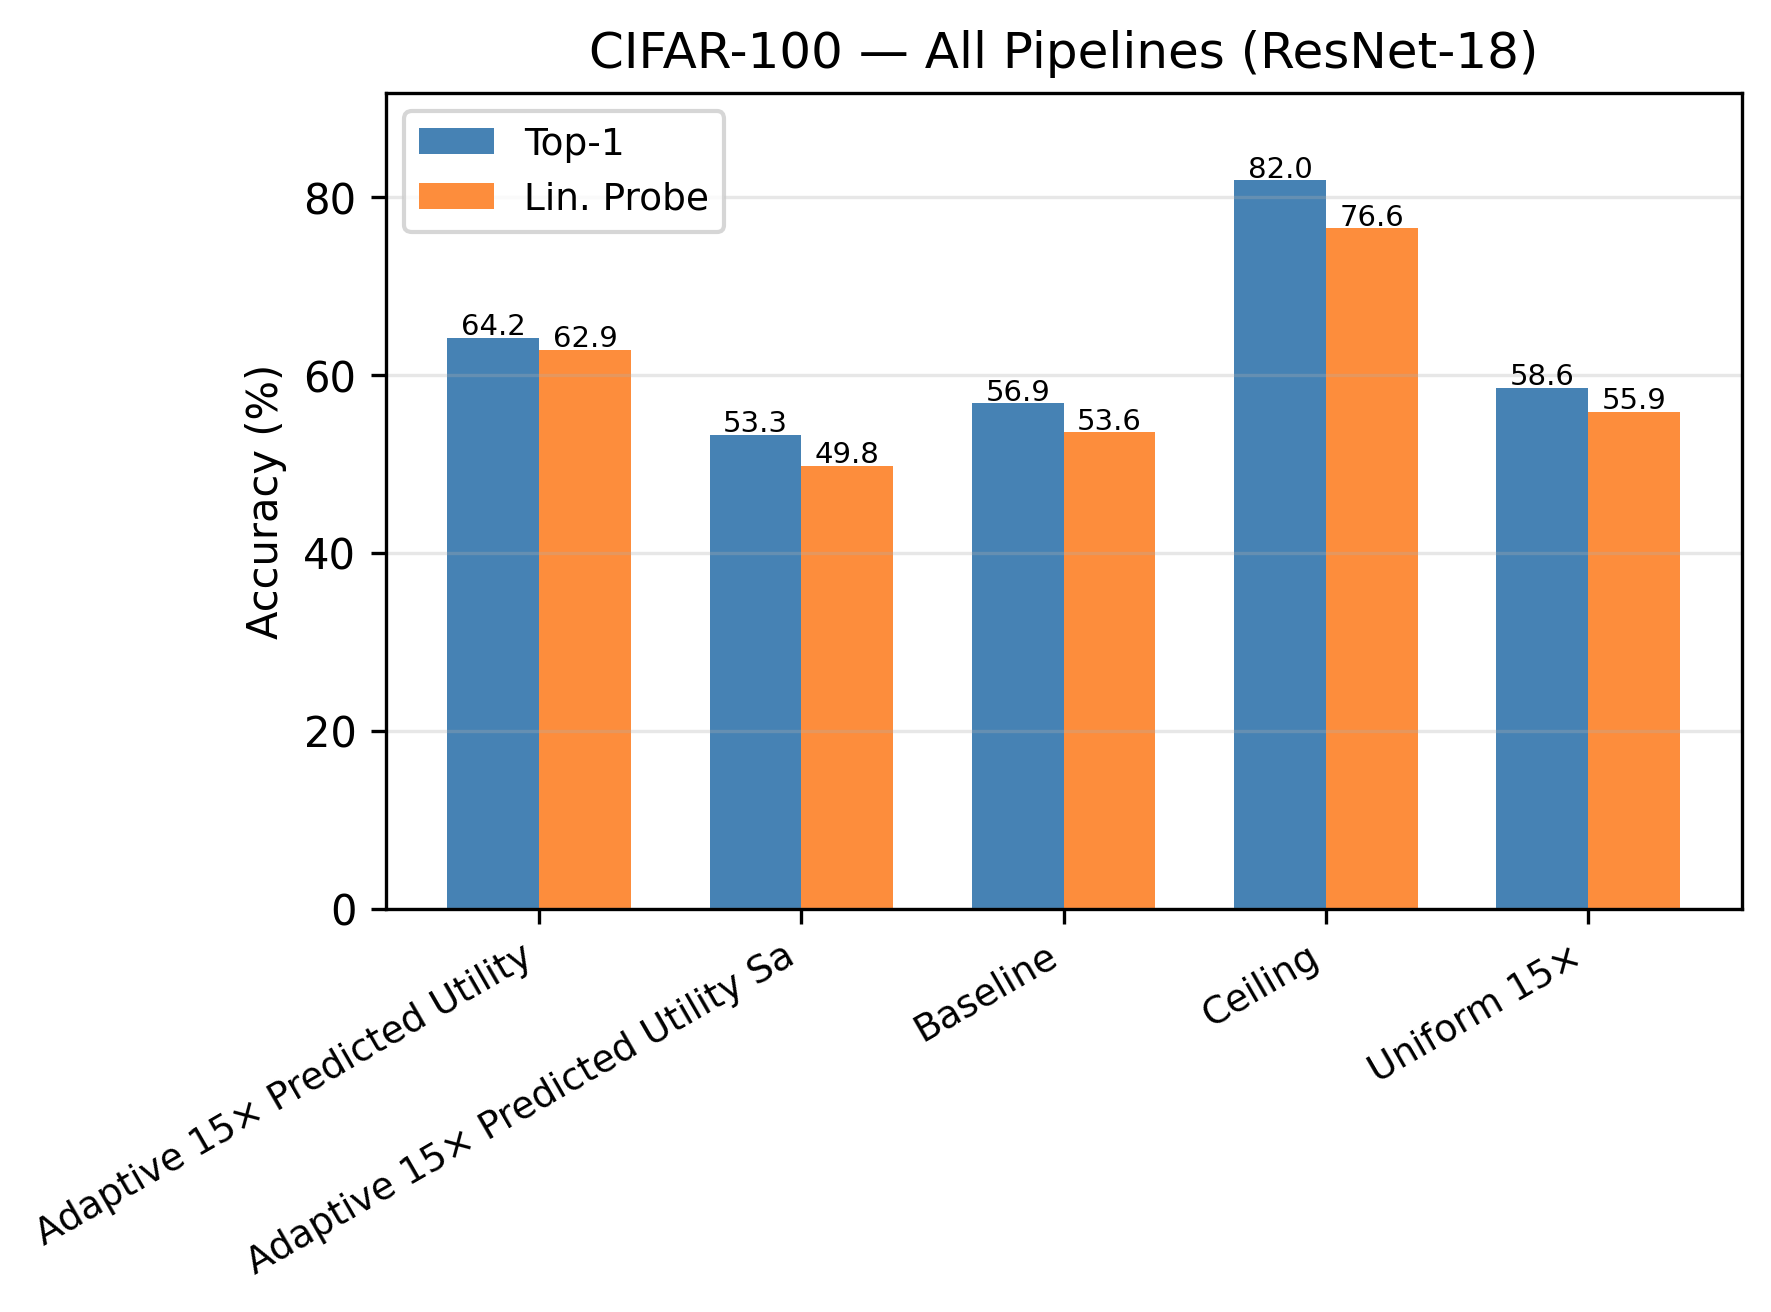

In [15]:
display(Image(filename="figures/stage2/fig9_cifar100_summary.png", width=900))

### Figure 10: Style Alignment Ablation (CIFAR-100)

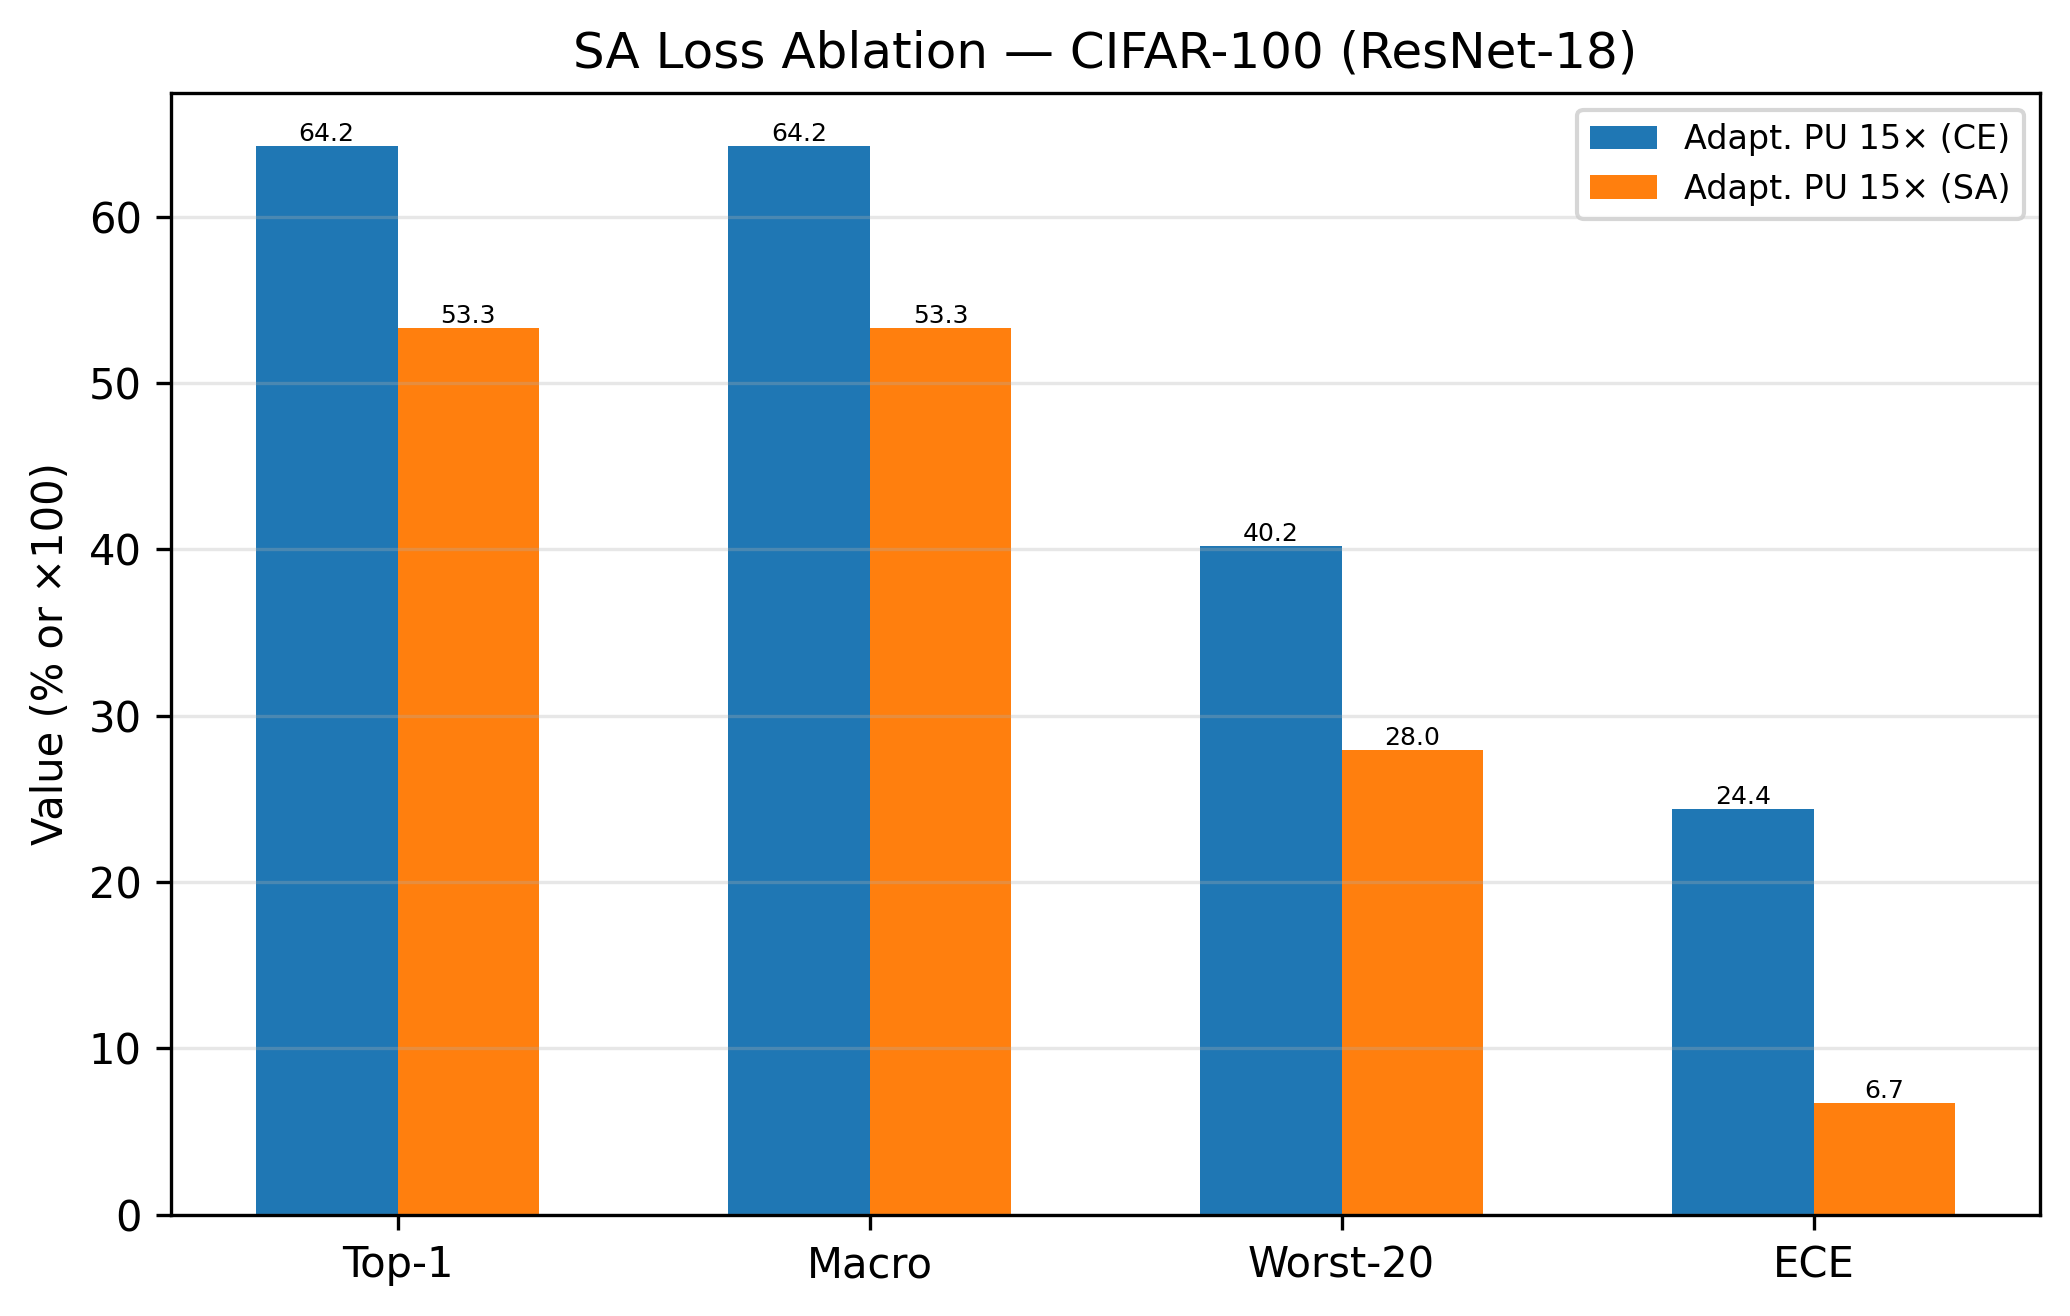

In [16]:
display(Image(filename="figures/stage2/fig10_sa_ablation_cifar.png", width=900))

## Full Metrics Dump

Complete metrics for every experiment run.


In [17]:
for key in sorted(all_metrics.keys()):
    m = all_metrics[key]
    print(f"\n{'='*80}")
    print(f"  {key}")
    print(f"{'='*80}")
    for k, v in sorted(m.items()):
        if k == "corruption" and isinstance(v, dict):
            print(f"  {k}:")
            for ck, cv in v.items():
                print(f"    {ck}: {cv}")
        elif k == "run_dir":
            continue
        else:
            print(f"  {k}: {v}")



  cifar100/adaptive_15x_predicted_utility/resnet18
  corruption:
    clean: 0.6423
    gaussian_noise: 0.0248
    blur: 0.6328
    brightness: 0.6217
  ece: 0.24409461888968945
  ece_after_scaling: 0.04950708950571715
  feature_effective_rank: 35.99526737766425
  linear_probe_top1: 0.6288
  macro_acc: 0.6422999999999999
  mean_corruption_acc: 0.4264333333333334
  top1: 0.6423
  top5: 0.8681
  worst_k_acc: 0.402

  cifar100/adaptive_15x_predicted_utility_sa/resnet18
  corruption:
    clean: 0.5333
    gaussian_noise: 0.037
    blur: 0.5283
    brightness: 0.5179
  ece: 0.06734625701159239
  ece_after_scaling: 0.058510714565962546
  feature_effective_rank: 28.97930945481807
  linear_probe_top1: 0.4982
  macro_acc: 0.5333000000000001
  mean_corruption_acc: 0.3610666666666667
  top1: 0.5333
  top5: 0.8175
  worst_k_acc: 0.2795

  cifar100/baseline/resnet18
  corruption:
    clean: 0.569
    gaussian_noise: 0.1238
    blur: 0.5632
    brightness: 0.5436
  ece: 0.14699022875875234
  ece_aft